In [1]:
import os

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

x_train_mnist = x_train_mnist / 255.0
x_test_mnist = x_test_mnist / 255.0

def load_custom_dataset(path):
    images, labels = [], []
    for label in os.listdir(path):
        for img_name in os.listdir(os.path.join(path, label)):
            img = Image.open(os.path.join(path, label, img_name)).convert("L")
            img_array = np.array(img) / 255.0
            images.append(img_array)
            labels.append(int(label))
    return np.array(images), np.array(labels)

x_custom, y_custom = load_custom_dataset("dataset")

x_data = np.concatenate([x_train_mnist, x_test_mnist, x_custom], axis=0)
y_data = np.concatenate([y_train_mnist, y_test_mnist, y_custom], axis=0)

x_data = x_data.reshape(-1, 28, 28, 1)

In [3]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

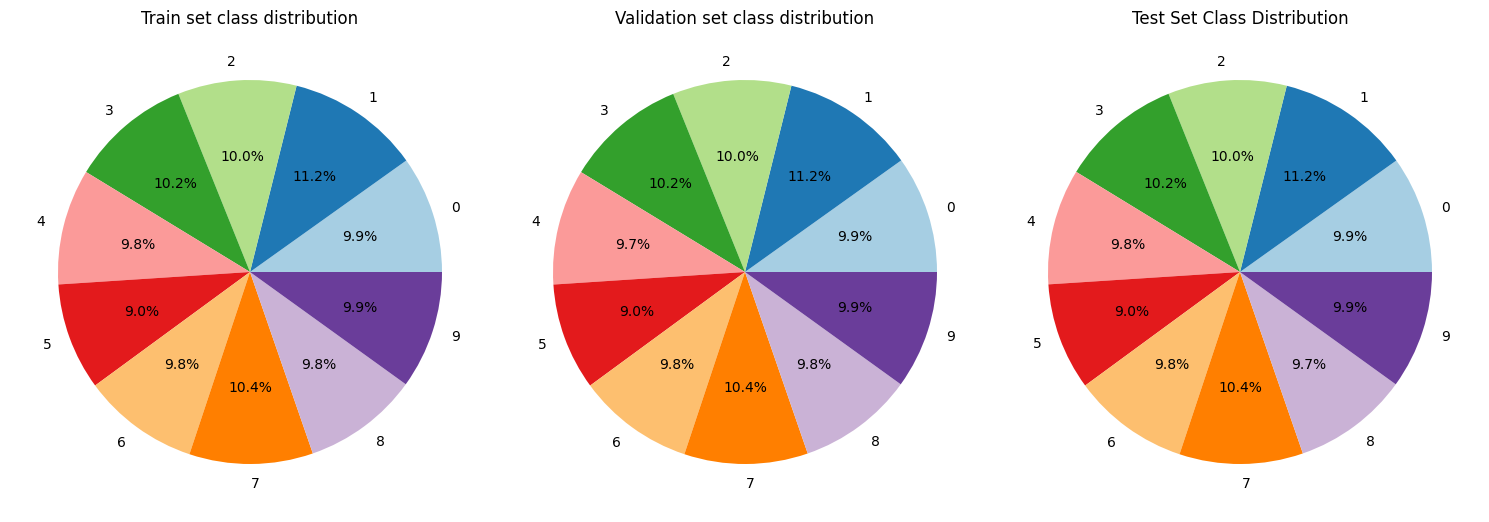

In [4]:
train_counts = np.bincount(y_train)
val_counts = np.bincount(y_val)
test_counts = np.bincount(y_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].pie(train_counts, labels=np.arange(len(train_counts)), colors=plt.cm.Paired.colors, autopct='%1.1f%%')
axes[0].set_title("Train set class distribution")

axes[1].pie(val_counts, labels=np.arange(len(val_counts)), colors=plt.cm.Paired.colors, autopct='%1.1f%%')
axes[1].set_title("Validation set class distribution")

axes[2].pie(test_counts, labels=np.arange(len(test_counts)), colors=plt.cm.Paired.colors, autopct='%1.1f%%')
axes[2].set_title("Test Set Class Distribution")

plt.tight_layout()
plt.show()

In [5]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

datagen.fit(x_train)

In [6]:
x_val = x_train[-len(x_val):]
y_val = y_train[-len(x_val):]